# CNN Visual Grader (MobileNetV2 Experimentation)
**Objective:** Fine-tune a pre-trained MobileNetV2 model to predict an engineered, log-scaled sales target based solely on product images. 

**Professional Standards Implemented:**
* Target distribution EDA.
* 80/20 `train_test_split`.
* Data augmentation to prevent overfitting.
* Early stopping and model checkpointing to preserve the best weights.

## Setup and Imports

In [1]:
# Imports:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

2026-06-30 13:07:41.811263: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-30 13:07:41.842193: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-30 13:07:42.582651: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/shail/miniconda3/envs/tf-gpu/lib/python3.11/site-packages/keras/src/export/tf2onnx_li

In [2]:
# Ensuring GPU Memory Growth:
gpu = tf.config.experimental.list_physical_devices('GPU')

if gpu:
    try:
        for g in gpu:
            tf.config.experimental.set_memory_growth(g, True)
    except RuntimeError as e:
        print(e)

print(f"TensorFlow version: {tf.__version__}")
print(f"Num GPUs Available: {len(gpu)}")

TensorFlow version: 2.20.0
Num GPUs Available: 1


## Data Loading and Validation

In [3]:
# Data Directory Paths:
IMAGE_DIR= os.path.abspath('../data/images_10k/')
TARGET_CSV= os.path.abspath('../data/processed/cnn_proxy_targets_10k.csv')

In [4]:
# Loading Data:
df= pd.read_csv(TARGET_CSV,
                dtype= {'article_id': str})
df['file_path']= df['article_id'].apply(lambda x: os.path.join(IMAGE_DIR, f"{x}.jpg"))

In [5]:
df.head()

,article_id,total_sales,total_sales_log,cnn_target_scaled,file_path
0,0111593001,13888,9.538852,0.873014,/home/shail/trendsight/data/images_10k/0111593...
1,0112679048,3,1.386294,0.068409,/home/shail/trendsight/data/images_10k/0112679...
2,0114428030,101,4.624973,0.388046,/home/shail/trendsight/data/images_10k/0114428...
3,0118458004,230,5.442418,0.468722,/home/shail/trendsight/data/images_10k/0118458...
4,0118458028,35,3.583519,0.285261,/home/shail/trendsight/data/images_10k/0118458...


In [6]:
df.shape

(10000, 5)

In [7]:
# Verifying Image Existence:
df['image_exists']= df['file_path'].apply(os.path.exists)
missing_count= (~df['image_exists']).sum()
print(f"Missing Images Dropped: {missing_count}")
df= df[df['image_exists']].copy()

print(f"DataFrame Shape After Dropping Missing Images: {df.shape}")

Missing Images Dropped: 39
DataFrame Shape After Dropping Missing Images: (9961, 6)


## Target Variable Analysis

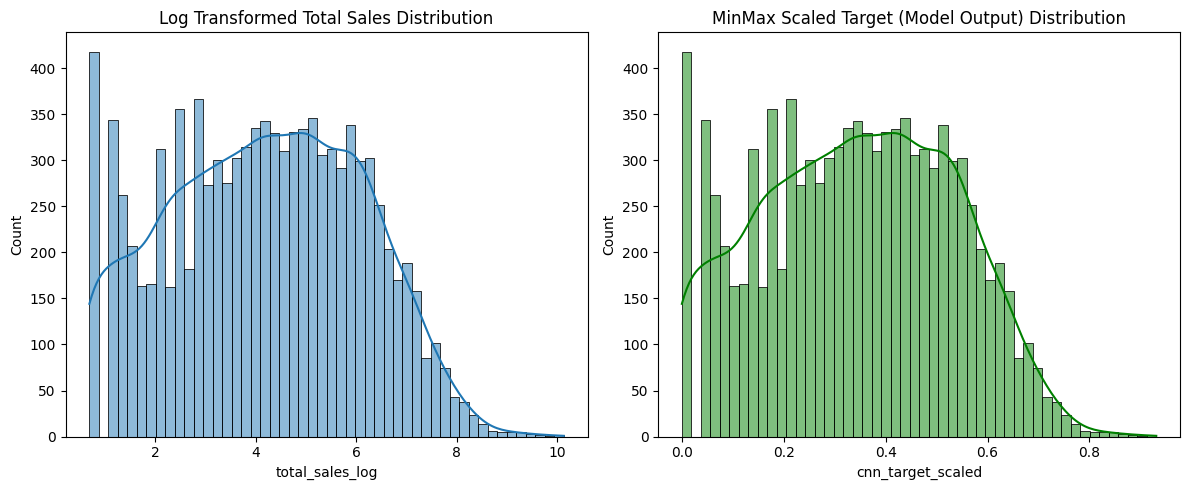

In [8]:
# Visualizing Target Variable to Ensure already applied log-transform + MinMax Scale is healthy:

plt.figure(figsize= (12,5))

plt.subplot(1,2,1)
sns.histplot(df['total_sales_log'], bins= 50, kde= True)
plt.title('Log Transformed Total Sales Distribution')

plt.subplot(1,2,2)
sns.histplot(df['cnn_target_scaled'], bins= 50, kde= True, color= 'green')
plt.title('MinMax Scaled Target (Model Output) Distribution')

plt.tight_layout()
plt.show()

## Train Test Split

In [9]:
train_df, test_df= train_test_split(df, test_size= 0.2, random_state= 42)
print(f"Train DataFrame Shape: {train_df.shape}")
print(f"Test DataFrame Shape: {test_df.shape}")

Train DataFrame Shape: (7968, 6)
Test DataFrame Shape: (1993, 6)


## Data Pipleline with Data Augmentation

In [10]:
# Variables:
BATCH_SIZE= 32
IMG_SIZE= (224, 224)

In [11]:
# Data Augmentation Layer:
data_augmetnation= tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
])

I0000 00:00:1782824865.508579    4906 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9507 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [12]:
# Processing Images:
def process_image(file_path, label):

    # Read the image from the file path
    image = tf.io.read_file(file_path)
    # Decode the image to a tensor
    image = tf.image.decode_jpeg(image, channels= 3)
    # Resize the image to the desired size
    image = tf.image.resize(image, IMG_SIZE)
    # Normalize the pixel values to [-1, 1] as per MobileNetV2 requirements
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)

    return image, label

In [13]:
# Building TensorFlow Dataset:
def build_dataset(dataframe, is_training= True):
    paths= dataframe['file_path'].values
    labels= dataframe['cnn_target_scaled'].values

    ds= tf.data.Dataset.from_tensor_slices((paths, labels))
    ds= ds.map(process_image, num_parallel_calls= tf.data.AUTOTUNE)

    if is_training:

        # Shuffling and Augmenting Data only while Training:
        ds= ds.shuffle(buffer_size= len(dataframe))
        ds= ds.map(lambda x, y: (data_augmetnation(x, training= True), y), 
                   num_parallel_calls= tf.data.AUTOTUNE)
    
    ds= ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    return ds

In [14]:
# Training and Validation Datasets:
train_ds= build_dataset(train_df, is_training= True)
val_ds= build_dataset(test_df, is_training= False)

## Model Architecture

In [15]:
# Loading Base Model:
base_model= MobileNetV2(weights= 'imagenet', include_top= False, input_shape= (224, 224, 3))

# Freezing base Model:
base_model.trainable= False

In [16]:
# Model Architecture:
inputs= Input(shape= (224, 224, 3))
x= base_model(inputs, training= False)
x= GlobalAveragePooling2D()(x)
x= Dropout(0.2)(x)
x= Dense(128, activation= 'relu')(x)
x= Dropout(0.2)(x)

outputs= Dense(1, activation= 'linear')(x)

model= Model(inputs, outputs)

model.compile(
    optimizer= Adam(learning_rate= 0.001),
    loss= 'mse',
    metrics= ['mae']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Callbacks and Model Training

In [17]:
# Setting up Model Checkpoint Path:
checkpoint_path= os.path.abspath('../data/processed/best_visual_grader.h5')

In [18]:
# Model Callbacks:
callbacks= [
    EarlyStopping(monitor= 'val_loss',
                  patience= 3,
                  restore_best_weights= True,
                  verbose= 1),
    
    ModelCheckpoint(filepath= checkpoint_path,
                    monitor= 'val_loss',
                    save_best_only= True,
                    verbose= 1),

    ReduceLROnPlateau(monitor= 'val_loss',
                      factor= 0.2,
                      patience= 2,
                      min_lr= 1e-6,
                      verbose= 1)
]

In [19]:
# Model Training:
history= model.fit(
    train_ds,
    validation_data= val_ds,
    epochs= 50,
    callbacks= callbacks
)

Epoch 1/50


2026-06-30 13:07:52.581557: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f3cb4110640 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-06-30 13:07:52.581583: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4080 Laptop GPU, Compute Capability 8.9
2026-06-30 13:07:52.657904: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-06-30 13:07:53.120853: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701
2026-06-30 13:07:53.254356: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-06-30 13:07:53.

249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.3674 - mae: 0.3771

2026-06-30 13:08:16.611530: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-30 13:08:16.777990: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_loss improved from None to 0.04458, saving model to /home/shail/trendsight/data/processed/best_visual_grader.h5


...


Epoch 4: finished saving model to /home/shail/trendsight/data/processed/best_visual_grader.h5
249/249 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - loss: 0.0319 - mae: 0.1454 - val_loss: 0.0345 - val_mae: 0.1552 - learning_rate: 0.0010
Epoch 5/50
247/249 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0313 - mae: 0.1446
Epoch 5: val_loss improved from 0.03449 to 0.03390, saving model to /home/shail/trendsight/data/processed/best_visual_grader.h5



Epoch 5: finished saving model to /home/shail/trendsight/data/processed/best_visual_grader.h5
249/249 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - loss: 0.0307 - mae: 0.1426 - val_loss: 0.0339 - val_mae: 0.1538 - learning_rate: 0.0010
Epoch 6/50
247/249 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0305 - mae: 0.1422
Epoch 6: val_loss did not improve from 0.03390
249/249 ━━━━━━━━━━━━━━━━━━━━ 16s 46ms/step - loss: 0.0303 - mae: 0.1418 - val_loss: 0.0347 - val_mae: 0.1559 - learning_rate: 0.0010
Epoch 7/50
247/249 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0289 - mae: 0.1397
Epoch 7: val_loss improved from 0.03390 to 0.03214, saving model to /home/shail/trendsight/data/processed/best_visual_grader.h5



Epoch 7: finished saving model to /home/shail/trendsight/data/processed/best_visual_grader.h5
249/249 ━━━━━━━━━━━━━━━━━━━━ 16s 49ms/step - loss: 0.0293 - mae: 0.1397 - val_loss: 0.0321 - val_mae: 0.1498 - learning_rate: 0.0010
Epoch 8/50
247/249 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0286 - mae: 0.1380
Epoch 8: val_loss did not improve from 0.03214
249/249 ━━━━━━━━━━━━━━━━━━━━ 16s 49ms/step - loss: 0.0287 - mae: 0.1383 - val_loss: 0.0336 - val_mae: 0.1533 - learning_rate: 0.0010
Epoch 9/50
247/249 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0285 - mae: 0.1379
Epoch 9: val_loss improved from 0.03214 to 0.03110, saving model to /home/shail/trendsight/data/processed/best_visual_grader.h5



Epoch 9: finished saving model to /home/shail/trendsight/data/processed/best_visual_grader.h5
249/249 ━━━━━━━━━━━━━━━━━━━━ 16s 48ms/step - loss: 0.0284 - mae: 0.1374 - val_loss: 0.0311 - val_mae: 0.1462 - learning_rate: 0.0010
Epoch 10/50
248/249 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0278 - mae: 0.1353
Epoch 10: val_loss did not improve from 0.03110
249/249 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - loss: 0.0280 - mae: 0.1361 - val_loss: 0.0336 - val_mae: 0.1530 - learning_rate: 0.0010
Epoch 11/50
247/249 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0278 - mae: 0.1361
Epoch 11: val_loss improved from 0.03110 to 0.03101, saving model to /home/shail/trendsight/data/processed/best_visual_grader.h5



Epoch 11: finished saving model to /home/shail/trendsight/data/processed/best_visual_grader.h5

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
249/249 ━━━━━━━━━━━━━━━━━━━━ 17s 51ms/step - loss: 0.0274 - mae: 0.1351 - val_loss: 0.0310 - val_mae: 0.1463 - learning_rate: 0.0010
Epoch 12/50
248/249 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0258 - mae: 0.1310
Epoch 12: val_loss did not improve from 0.03101
249/249 ━━━━━━━━━━━━━━━━━━━━ 17s 51ms/step - loss: 0.0262 - mae: 0.1316 - val_loss: 0.0319 - val_mae: 0.1488 - learning_rate: 2.0000e-04
Epoch 13/50
247/249 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0260 - mae: 0.1315
Epoch 13: val_loss did not improve from 0.03101

Epoch 13: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.
249/249 ━━━━━━━━━━━━━━━━━━━━ 17s 51ms/step - loss: 0.0263 - mae: 0.1325 - val_loss: 0.0313 - val_mae: 0.1472 - learning_rate: 2.0000e-04
Epoch 14/50
247/249 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0260 - mae: 0

# Model Evaluation and Learning Curves

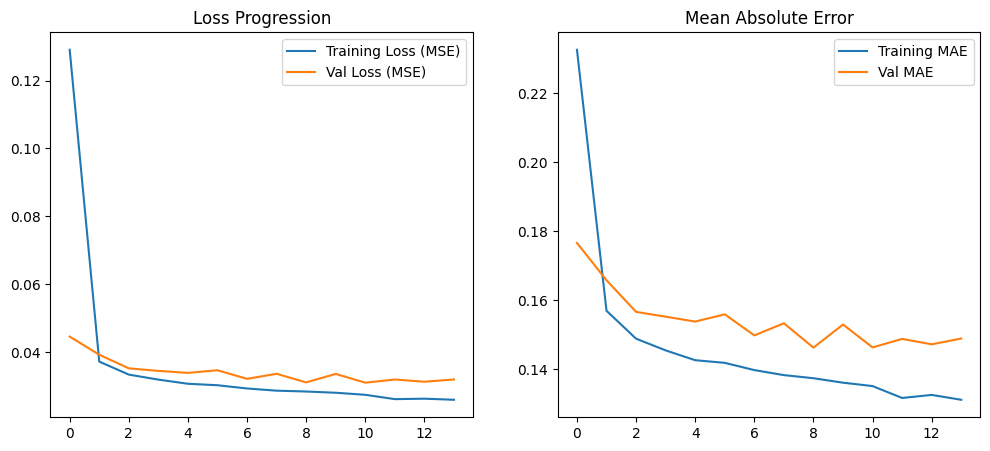

In [20]:
# Plotting Training History:
plt.figure(figsize= (12,5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label= 'Training Loss (MSE)')
plt.plot(history.history['val_loss'], label= 'Val Loss (MSE)')
plt.legend()
plt.title('Loss Progression')

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label= 'Training MAE')
plt.plot(history.history['val_mae'], label= 'Val MAE')
plt.legend()
plt.title('Mean Absolute Error')

plt.show()

In [21]:
# Model Evaluation on the Best Restored Weights:
val_loss, val_mae= model.evaluate(val_ds)
print(f"Final Validation MAE: {val_mae:.4f}")
print(f"Final Validation Loss: {val_loss:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0310 - mae: 0.1463
Final Validation MAE: 0.1463
Final Validation Loss: 0.0310


## Generating Visual Trend Scores

In [22]:
# Predicting on Full Dataset using Best Restored Model:
full_ds= build_dataset(dataframe= df,
                       is_training= False)
df['CNN_Visual_Trend_Score']= model.predict(full_ds)

312/312 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step


In [23]:
df.head()

,article_id,total_sales,total_sales_log,cnn_target_scaled,file_path,image_exists,CNN_Visual_Trend_Score
0,0111593001,13888,9.538852,0.873014,/home/shail/trendsight/data/images_10k/0111593...,True,0.305146
1,0112679048,3,1.386294,0.068409,/home/shail/trendsight/data/images_10k/0112679...,True,0.236609
2,0114428030,101,4.624973,0.388046,/home/shail/trendsight/data/images_10k/0114428...,True,0.389910
3,0118458004,230,5.442418,0.468722,/home/shail/trendsight/data/images_10k/0118458...,True,0.275760
4,0118458028,35,3.583519,0.285261,/home/shail/trendsight/data/images_10k/0118458...,True,0.230257


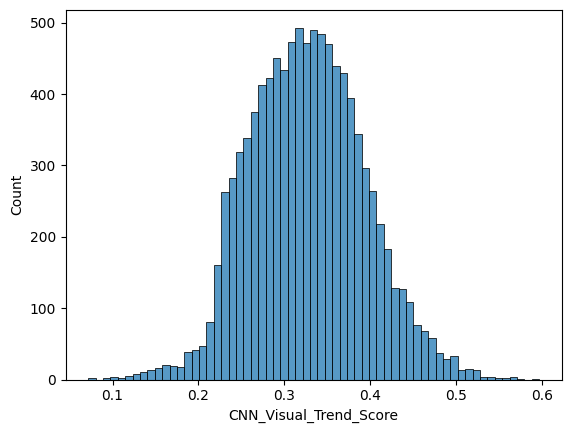

In [24]:
sns.histplot(df['CNN_Visual_Trend_Score'])
plt.show()

In [32]:
# Saving Just The ID and Visual Trend Score:
output_df= df[['article_id', 'CNN_Visual_Trend_Score']]
output_df.to_csv(os.path.abspath('../data/processed/cnn_visual_scores.csv'),
                                              index= False)